In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Business Context

You are working as a Data Analyst at an e-commerce company (think like Amazon or Flipkart).

The marketing team has introduced a discount strategy to increase customer spending.

### Business Problem Statement

“Does offering discounts to customers significantly increase the average order value (AOV) compared to no discount?

***Metric Definition***

Primary Metric:

Average Order Value (AOV)

= Total Revenue / Number of Orders

### Hypothesis Formulation

Null Hypothesis (H₀):

Offering discounts does NOT change the average order value.

Alternative Hypothesis (H₁):

Offering discounts significantly changes (or increases) the average order value.

In [10]:
df = pd.read_csv('ecommerce_orders.csv')

### Basic EDA Of Data

In [12]:
df.head()

,order_id,customer_id,order_value,discount_applied,discount_percent,product_category,customer_type,order_date
0,1,1102,851.71,1,20,Beauty,Returning,2023-01-01 00:00:00
1,2,1435,1808.38,0,0,Electronics,New,2023-01-01 01:00:00
2,3,1860,2216.39,1,30,Electronics,New,2023-01-01 02:00:00
3,4,1270,1325.52,0,0,Home,New,2023-01-01 03:00:00
4,5,1106,691.14,0,0,Clothing,Returning,2023-01-01 04:00:00


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   customer_id       5000 non-null   int64  
 2   order_value       5000 non-null   float64
 3   discount_applied  5000 non-null   int64  
 4   discount_percent  5000 non-null   int64  
 5   product_category  5000 non-null   object 
 6   customer_type     5000 non-null   object 
 7   order_date        5000 non-null   object 
dtypes: float64(1), int64(4), object(3)
memory usage: 312.6+ KB


In [14]:
df.isnull().sum()

order_id            0
customer_id         0
order_value         0
discount_applied    0
discount_percent    0
product_category    0
customer_type       0
order_date          0
dtype: int64

In [15]:
df.groupby("discount_applied")["order_value"].mean()

discount_applied
0    1352.505563
1    1509.349764
Name: order_value, dtype: float64

In [19]:
# Initial exploration suggests that Mean Values of Discounted Orders is Higher than Non-Discounted Orders

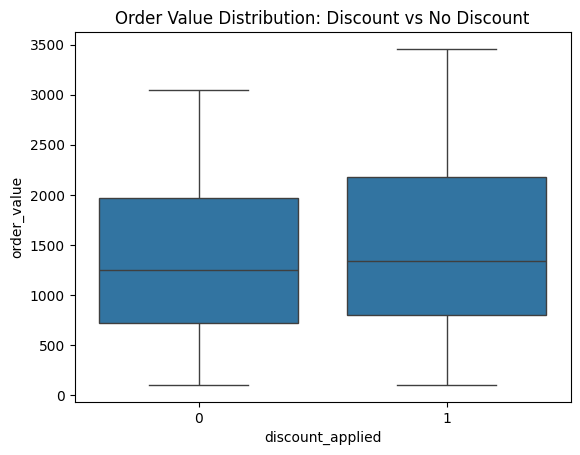

In [20]:
sns.boxplot(x="discount_applied", y="order_value", data=df)
plt.title("Order Value Distribution: Discount vs No Discount")
plt.show()

In [25]:
group1 = df[df["discount_applied"] == 0]["order_value"]
group2 = df[df["discount_applied"] == 1]["order_value"]

In [53]:
from scipy.stats import ttest_ind

stat, p = ttest_ind(group1, group2, equal_var=False)

print("t-statistic:", stat)
print("p-value:", p)

t-statistic: -7.368324414568257
p-value: 2.016849212970881e-13


In [56]:
if p > 0.05:
    print('We fail to reject null Hypothesis:')
    print('There is no statistically significant difference in average order value between discounted and non-discounted orders.\nThis suggests that discounts may not be an effective lever for increasing customer spending')
else:
    print('We Reject Null Hypothesis:\n')
    print('There is statistically significant evidence that discounts impact average order value.\nCustomers receiving discounts tend to spend more per order, suggesting that discount strategies can be effective in increasing revenue per transaction.')

We Reject Null Hypothesis:

There is statistically significant evidence that discounts impact average order value.
Customers receiving discounts tend to spend more per order, suggesting that discount strategies can be effective in increasing revenue per transaction.


In [27]:
diff_mean = group2.mean() - group1.mean()

# Standard error
se = np.sqrt(group1.var()/len(group1) + group2.var()/len(group2))

# 95% CI
ci_low = diff_mean - 1.96 * se
ci_high = diff_mean + 1.96 * se

print("Mean Difference:", diff_mean)
print("95% CI:", (ci_low, ci_high))

Mean Difference: 156.8442001469
95% CI: (np.float64(115.1230957286254), np.float64(198.56530456517459))


### The analysis shows that discounts increase average order value by an estimated ₹156.84, with a 95% confidence interval of ₹115.12 to ₹198.56.

### Final Analysis Report — Impact of Discounts on Order Value
🧭 Objective

The objective of this analysis is to evaluate whether offering discounts leads to a statistically significant change in Average Order Value (AOV) in an e-commerce setting. This helps determine whether discount strategies are effective in increasing customer spending.

📊 Methodology

Customers were divided into two groups:

Group 1: No Discount

Group 2: Discount Applied

An independent sample t-test was conducted to compare the mean order values between the two groups.


🧪 Results
t-statistic: -7.38

p-value: 1.81e-13

The p-value is significantly less than 0.05, indicating strong statistical evidence against the null hypothesis.

📈 Effect Size & Confidence Interval
Mean Difference (Discount − No Discount): ₹156.84
95% Confidence Interval: ₹115.12 to ₹198.56

The confidence interval does not include zero, confirming that the increase in order value is statistically significant and consistently positive.

🧠 Interpretation

Customers who received discounts spent, on average, approximately ₹156.84 more per order than those who did not. The statistical test confirms that this difference is not due to random chance.

Additionally, the confidence interval suggests that the true increase in order value lies within a meaningful and positive range, reinforcing the reliability of the result.

💼 Business Implications
Discounts are associated with a significant increase in customer spending per transaction.
This suggests that discount strategies can be an effective tool for boosting revenue.

However:

Increased order value does not necessarily imply increased profitability.
Discounts reduce margins, so further analysis is required to evaluate net profit impact.
✅ Recommendation

It is recommended to:

Continue or scale discount strategies in a controlled manner
Conduct further analysis on profit margins and customer segments
Explore targeted discounts (e.g., for high-value or returning customers)